# LSZ Spectroscopy — main driver notebook

All physics, Fourier analysis, spectrum reconstruction, and state-vector validation live in `src/`. This notebook only wires them together.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('/Users/omichel/Desktop/qilimanjaro/projects/LZS_spectroscopy/lsz_spectroscopy/src')

from lsz_experiment import LSZ_experiment, run_experiment_sweep
from diagnostics import run_full_diagnostics

## Parameters

In [7]:
epsilon = 1
alpha = 1
ramp_time = 0.75
n_steps = 201
dt = 0.05
r_noise = False
w_noise = True

# 2 qubit example (GHz)
local_z_list = np.array([2.1, 1.1])
zz_terms = np.array([0.35])

t1_rates = [0.11, 0.1]
t2_rates = [0.01, 0.015]

#3 qubit example
# local_z_list = np.array([2.1, 3.05, 1.78])
# zz_terms = np.array([1.22, 0.54, 0.3])

# t1_rates = [0.005, 0.0051, 0.0048]
# t2_rates = [0.01, 0.012, 0.0098]

nqubits = len(local_z_list)
max_wait_time = 50.0/alpha
n_sims = int(max_wait_time*20)

tw_l = np.linspace(0, max_wait_time, n_sims)

H_target_dict = {'one_body': local_z_list, 'two_body': zz_terms}

print('Max wait time:', max_wait_time)
print('dt:', dt)
print('Number of simulations:', n_sims)

Max wait time: 50.0
dt: 0.05
Number of simulations: 1000


## Schedule and spectrum preview

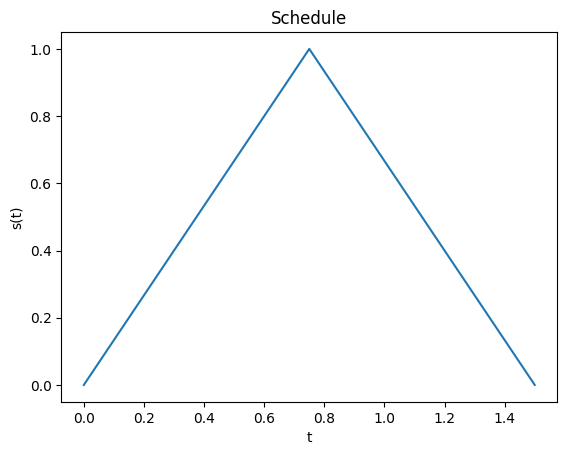

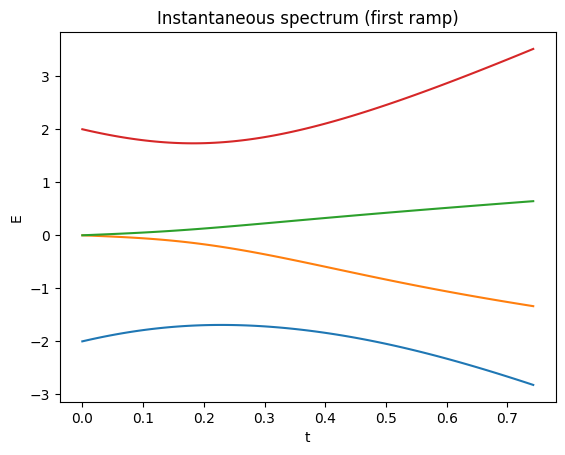

Spectrum at midpoint: [-2.85 -1.35  0.65  3.55]


In [8]:
preview = LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, 0, dt)

t_list, s_list = preview.show_schedule(n_steps)
plt.plot(t_list, s_list)
plt.xlabel('t'); plt.ylabel('s(t)'); plt.title('Schedule')
plt.show()

t_list, egvals, egvecs = preview.show_spectrum(n_steps)
midpoint = int(len(t_list)/2)
plt.plot(t_list[0:midpoint], egvals[0:midpoint])
plt.xlabel('t'); plt.ylabel('E'); plt.title('Instantaneous spectrum (first ramp)')
plt.show()

egvals_midpoint = egvals[midpoint]
print('Spectrum at midpoint:', egvals_midpoint)

## Run the experiment sweep

In [9]:
pc_list = run_experiment_sweep(
    nqubits, epsilon, H_target_dict, ramp_time, tw_l, dt,
    r_noise=r_noise, w_noise=w_noise,
    gamma_dec_list=None, gamma_dep_list=t2_rates,
)

## Full diagnostics

Fourier analysis + global fit + energy-difference matching + turnpike reconstruction + u_m / phi_m recovery + exact-state validation + (optional) dephasing comparison.

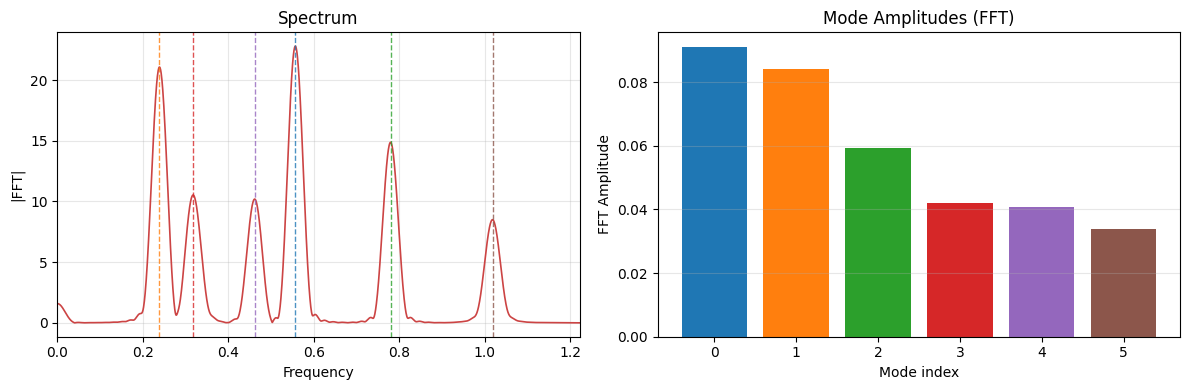


  #       Frequency   Phase (rad)
-----------------------------------
  1        0.556966        2.6417
  2        0.238941        1.0921
  3        0.779859        3.6291
  4        0.317705        1.5465
  5        0.461804        2.0824
  6        1.018590        4.8117


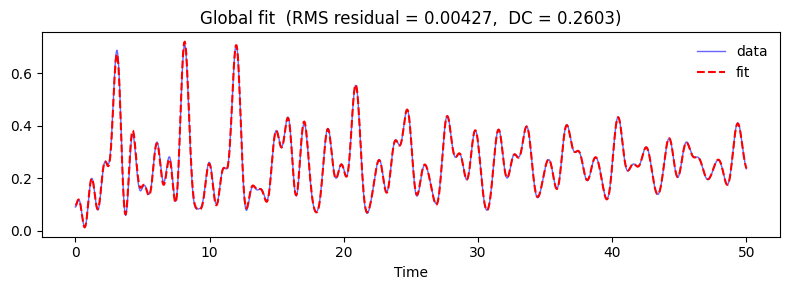

Amplitudes: [0.07450601 0.08733216 0.0483348  0.06813995 0.04151116 0.053582  ]
Decay rates: [0.02029851 0.03057638 0.02004583 0.05143801 0.03005284 0.04989264]
DC (fitted): 0.2603263585382614   DC (mean): 0.25712808403726606

                     Matched energy differences                     
--------------------------------------------------------------------
   #     Detected Δε         True Δε           Error       Error (%)
--------------------------------------------------------------------
   1        3.499518        3.500000       -0.000482          -0.014%
   2        1.501311        1.500000       +0.001311          +0.087%
   3        4.900000        4.900000       +0.000000          +0.000%
   4        1.996199        2.000000       -0.003801          -0.190%
   5        2.901597        2.900000       +0.001597          +0.055%
   6        6.399990        6.400000       -0.000010          -0.000%
--------------------------------------------------------------------
        

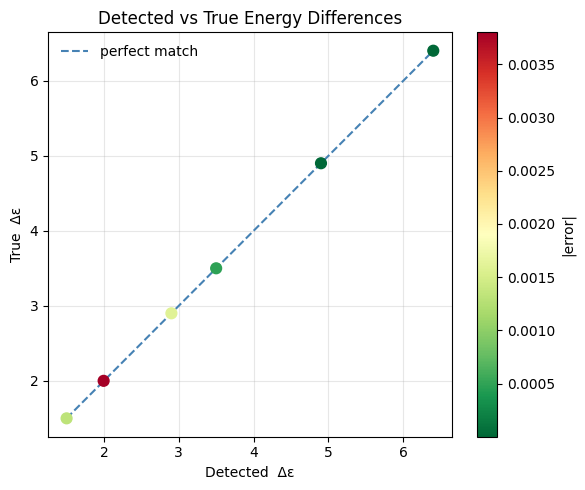

Incomplete Turnpike Solver
  Target levels:        4
  Expected differences: 6
  Observed differences: 6 (100%)

  Trying match threshold = 100% ... found solution explaining 6/6 (100%) of observations.

  Running greedy solver for comparison...
  Greedy explains 6/6 (100%)

  Final solution (backtracking):
    [np.float64(0.0), np.float64(1.5), np.float64(3.4995), np.float64(6.4)]
    Explains 6/6 observed differences (100%)

                  E0      E1      E2      E3
True:         0.0000  1.5000  3.5000  6.4000
Forward:      0.0000  1.5000  3.4995  6.4000  <-- best
Reversed:     0.0000  2.9005  4.9000  6.4000


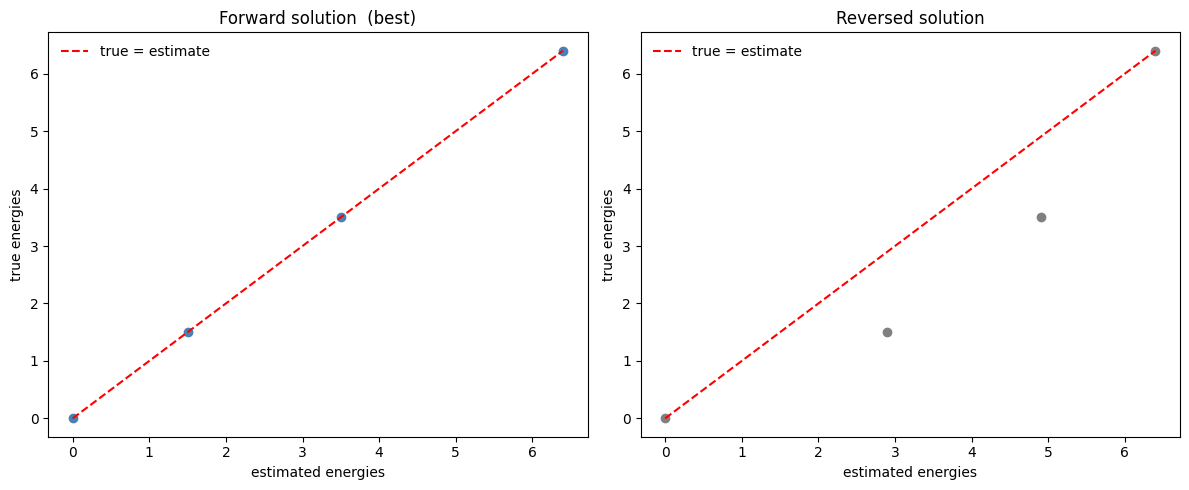

e_m:   [0.     1.5013 3.4995 6.4   ]
phi_m: [0.     2.5955 1.8208 0.7358]
u_m:   [0.5569 0.5307 0.491  0.415 ]
Exact |u_m|: [0.55638587 0.52726855 0.48863342 0.41672535]
Exact phases (mod pi, rel to u_0): [0.         2.56495554 1.828654   0.7515675 ]


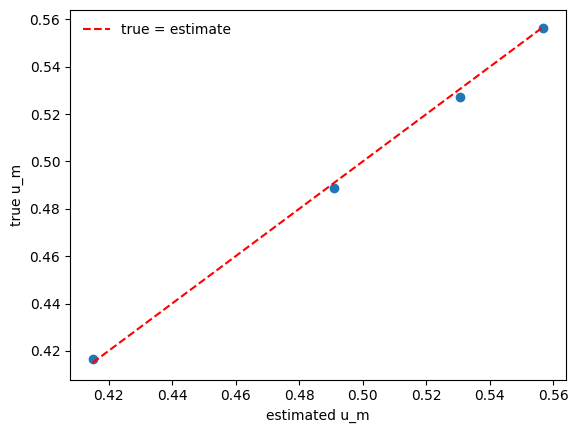

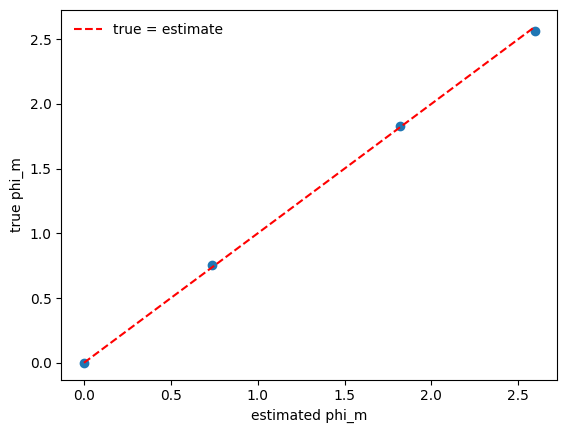

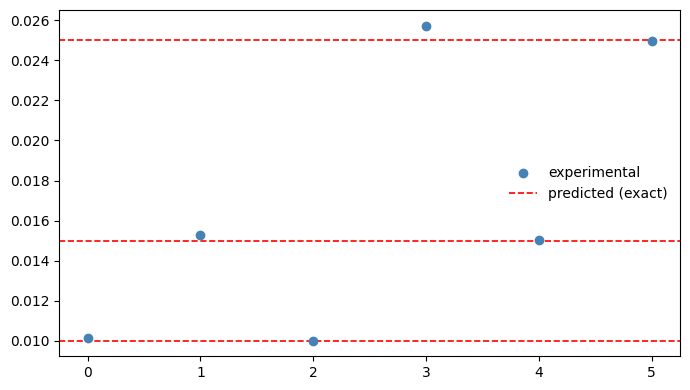

Possible lambdas (upper bound): [0.01  0.015 0.025]
Experimental lambdas: [0.02029851 0.03057638 0.02004583 0.05143801 0.03005284 0.04989264]


In [10]:
results = run_full_diagnostics(
    pc_list, tw_l, nqubits, epsilon, H_target_dict,
    ramp_time, dt, egvals_midpoint,
    w_noise=w_noise,
    t2_rates=t2_rates if w_noise else None,
)